In [12]:
# Import necessary libraries and modules
import pandas as pd
import pandapower as pp
import pandapower.networks as pn

from simulation_interface import GridSimulation
from typing import List
from pandapower import pandapowerNet
from sim_config import GridConfig, DataCenterConfig
from grid_regions import GridRegion
from grid_observer import plot_data, plot_metric_over_time
from datetime import datetime, timedelta
from generation_types import GenerationType

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [ ]:
# Define the grid configuration and data center configuration for the simulation
energy_profiles: dict[GridRegion, dict[GenerationType, float]] = {
    # Source: https://www.cer-rec.gc.ca/en/data-analysis/energy-markets/province-territory-energy-profiles/ontario.html
    GridRegion.CA_ON: {
        GenerationType.SOLAR: 0.041,
        GenerationType.WIND: 0.08,
        GenerationType.HYDRO_RIVER: 0.24,
        GenerationType.NUCLEAR: 0.55,
        GenerationType.GAS_COMBINED_CYCLE: 0.08,
        GenerationType.BIOMASS: 0.008,
        GenerationType.CRUDE_OIL: 0.001,
    },
    # Source: https://www.energy.ca.gov/data-reports/energy-almanac/california-electricity-data/2024-total-system-electric-generation
    GridRegion.US_CAL_CISO: {
        GenerationType.COAL: 0.0221,
        GenerationType.GAS_COMBINED_CYCLE: 0.3401,
        GenerationType.CRUDE_OIL: 0.0009,
        GenerationType.NUCLEAR: 0.0992,
        GenerationType.HYDRO_RIVER: 0.1106 + 0.0152,
        GenerationType.BIOMASS: 0.0194,
        GenerationType.GEOTHERMAL: 0.046,
        GenerationType.SOLAR: 0.213,
        GenerationType.WIND: 0.1189
    },
    # Source: https://www.ercot.com/gridmktinfo/dashboards/fuelmix
    GridRegion.US_TEX_ERCO: {
        GenerationType.SOLAR: 0.16,
        GenerationType.WIND: 0.27,
        GenerationType.GAS_COMBINED_CYCLE: 0.29,
        GenerationType.GAS_PEAKING: 0.06,
        GenerationType.COAL: 0.12,
        GenerationType.NUCLEAR: 0.08
    },
    # Source: https://www.eia.gov/states/VA/overview
    GridRegion.US_MIDA_PJM: {
        GenerationType.COAL: 0.026,
        GenerationType.GAS_COMBINED_CYCLE: 0.545,
        GenerationType.CRUDE_OIL: 0.003,
        GenerationType.SOLAR: 0.0325,
        GenerationType.WIND: 0.0325,
        GenerationType.NUCLEAR: 0.362
    }
}

# The sourced fuel-mix fractions don't all sum to exactly 1 (rounding, imports and
# "other" categories): US_MIDA_PJM sums to 1.001 (which would trip the >1 capacity
# guard in assign_grid_generation_profile) and US_CAL_CISO sums to 0.985. Normalize
# each profile so its shares sum to 1, preserving the sourced proportions while making
# every profile feasible and fully assigned.
def normalize_profile(profile: dict[GenerationType, float]) -> dict[GenerationType, float]:
    total = sum(profile.values())
    return {source: share / total for source, share in profile.items()}

energy_profiles = {region: normalize_profile(profile) for region, profile in energy_profiles.items()}

load_ids = []
grid_configs = []
for region in energy_profiles.keys():
    grid_configs.append(
        GridConfig(
            pp_grid = pn.case300(), # type: ignore
            region = region,
            energy_profile = energy_profiles[region]
        )
    )
    data_center_config = DataCenterConfig(
        load_share = 0.5, 
        onsite_overprovision_factor = 1.0,
        onsite_generation_source = GenerationType.GAS_COMBINED_CYCLE,
    )
    load_ids.append(grid_configs[-1].add_data_center(data_center_config))
    
    
# Initialize the grid simulation interface with the defined configurations
sim_interface = GridSimulation(
    grid_configs=grid_configs,
    shifting_threshold=10.0,
    enable_weather_variation=True
)

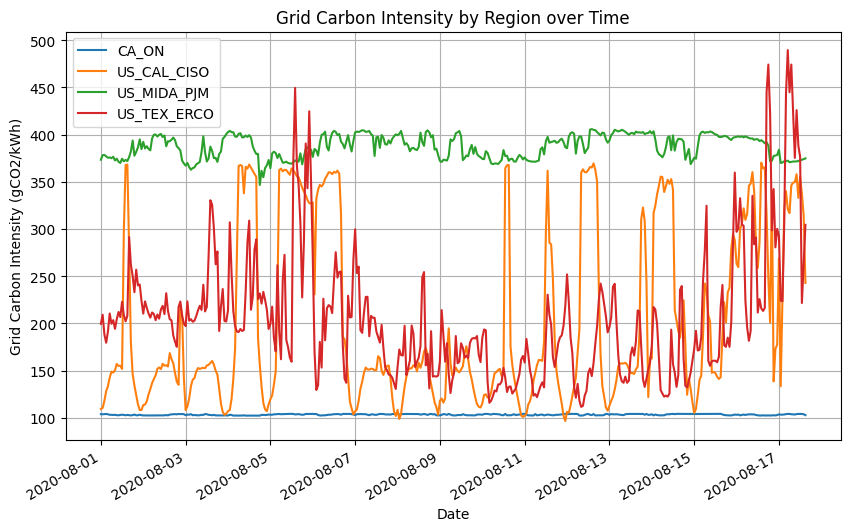

In [14]:
# Run the simulation over a sequence of hourly timesteps, recording metrics each step.
SIMULATION_START_TIME: datetime = datetime.strptime('2020-08-01 00:00:00', '%Y-%m-%d %H:%M:%S')
num_hours = 400
current_time = SIMULATION_START_TIME

for _ in range(num_hours):
    sim_interface.run_power_flow(date = current_time, observe = True)
    current_time += timedelta(hours = 1)

# Plot carbon intensity for all regions by date on a single figure. The observer's
# DataFrame has one row per region per timestamp, so one line is drawn per region.
metrics_df = sim_interface.observer.to_dataframe()
plot_metric_over_time(
    metrics_df = metrics_df,
    metric     = "carbon_intensity",
    title      = "Grid Carbon Intensity by Region over Time",
    y_label    = "Grid Carbon Intensity (gCO2/kWh)",
    x_label    = "Date"
)

In [15]:
grid = sim_interface._grids[0]
energy_profile = grid.get_energy_profile()
for gen_type, share in energy_profile.items():
    print(f"{gen_type.value}: {share:.2%}")


solar: 0.00%
solar_non_varying: 0.00%
wind: 0.00%
wind_non_varying: 0.00%
biomass: 0.00%
gas_combined_cycle: 0.00%
hydro_river: 0.00%
nuclear: 0.00%
oil: 0.00%


In [16]:
display(sim_interface._grids[0]._net.res_ext_grid)

,p_mw,q_mvar
0,-3.219152e-10,NaN


In [17]:
display(sim_interface._grids[0]._net.res_gen)

,p_mw,q_mvar,va_degree,vm_pu
0,1.000000e+02,NaN,66.556136,1.0
1,1.000000e+02,NaN,69.917136,1.0
2,1.000000e+02,NaN,61.782390,1.0
3,9.600000e+00,NaN,-12.519864,1.0
4,3.100000e+01,NaN,-65.791137,1.0
5,4.750000e+02,NaN,-55.844311,1.0
6,7.905000e+01,NaN,16.505144,1.0
7,4.781725e+01,NaN,1.620177,1.0
8,5.208000e+01,NaN,7.170032,1.0
9,6.727000e+01,NaN,-4.992590,1.0


In [18]:
display(sim_interface._grids[0]._net.ext_grid)

,name,bus,vm_pu,va_degree,slack_weight,in_service,max_p_mw,min_p_mw,max_q_mvar,min_q_mvar,controllable,p_mw,source_type
0,None,256,1.0507,0.0,1.0,True,0.0,-inf,10.0,0.0,True,0.0,coal


In [19]:
display(sim_interface._grids[0]._net.gen)

,name,bus,p_mw,vm_pu,sn_mva,min_q_mvar,max_q_mvar,scaling,slack,in_service,slack_weight,type,controllable,max_p_mw,min_p_mw,id_q_capability_characteristic,reactive_capability_curve,curve_style,power_limit,source_type,is_onsite_gen,is_backup_gen
0,None,7,0.0,1.0153,NaN,-10.00,10.00,1.0,False,True,0.0,None,True,100.000,0.0,<NA>,False,None,100.000,hydro_river,False,False
1,None,9,0.0,1.0205,NaN,-20.00,20.00,1.0,False,True,0.0,None,True,100.000,0.0,<NA>,False,None,100.000,gas_combined_cycle,False,False
2,None,18,0.0,1.0010,NaN,-20.00,20.00,1.0,False,True,0.0,None,True,100.000,0.0,<NA>,False,None,100.000,biomass,False,False
3,None,54,0.0,0.9583,NaN,-25.00,25.00,1.0,False,True,0.0,None,True,9.600,0.0,<NA>,False,None,100.000,wind,False,False
4,None,62,0.0,0.9632,NaN,12.00,35.00,1.0,False,True,0.0,None,True,31.000,0.0,<NA>,False,None,100.000,solar,False,False
5,None,68,0.0,1.0250,NaN,-240.00,240.00,1.0,False,True,0.0,None,True,475.000,0.0,<NA>,False,None,475.000,hydro_river,False,False
6,None,75,0.0,1.0520,NaN,-11.00,96.00,1.0,False,True,0.0,None,True,79.050,0.0,<NA>,False,None,255.000,solar,False,False
7,None,76,0.0,1.0520,NaN,-153.00,153.00,1.0,False,True,0.0,None,True,390.000,0.0,<NA>,False,None,390.000,nuclear,False,False
8,None,79,0.0,1.0000,NaN,-30.00,56.00,1.0,False,True,0.0,None,True,52.080,0.0,<NA>,False,None,168.000,solar,False,False
9,None,87,0.0,0.9900,NaN,-24.00,77.00,1.0,False,True,0.0,None,True,67.270,0.0,<NA>,False,None,217.000,solar,False,False


In [20]:
display(sim_interface._grids[0]._net.sgen)

,name,bus,p_mw,q_mvar,sn_mva,scaling,in_service,type,current_source,controllable,id_q_capability_characteristic,reactive_capability_curve,curve_style,min_p_mw,max_p_mw,power_limit,source_type,is_onsite_gen,is_backup_gen
0,None,43,0.0,-5.00,NaN,1.0,True,,True,True,<NA>,False,None,0.0,5.0000,5.0,biomass,False,False
1,None,185,0.0,14.20,NaN,1.0,True,,True,True,<NA>,False,None,0.0,21.0000,21.0,nuclear,False,False
2,None,228,0.0,17.00,NaN,1.0,True,,True,True,<NA>,False,None,0.0,23.0000,23.0,biomass,False,False
3,None,229,0.0,29.40,NaN,1.0,True,,True,True,<NA>,False,None,0.0,33.1000,33.1,nuclear,False,False
4,None,233,0.0,-26.50,NaN,1.0,True,,True,True,<NA>,False,None,0.0,14.9000,14.9,oil,False,False
5,None,238,0.0,1.40,NaN,1.0,True,,True,True,<NA>,False,None,0.0,11.1000,11.1,nuclear,False,False
6,None,241,0.0,-76.70,NaN,1.0,True,,True,True,<NA>,False,None,0.0,10.9152,113.7,wind,False,False
7,None,243,0.0,-34.17,NaN,1.0,True,,True,True,<NA>,False,None,0.0,100.0000,100.0,gas_combined_cycle,False,False


In [21]:
display(sim_interface._grids[0]._net.load)

,name,bus,p_mw,q_mvar,const_z_p_percent,const_z_q_percent,const_i_p_percent,const_i_q_percent,sn_mva,scaling,in_service,type,controllable,is_data_center,power_limit
0,None,0,90.00,49.00,0.0,0.0,0.0,0.0,NaN,1.0,True,None,False,True,11923.825
1,None,1,56.00,15.00,0.0,0.0,0.0,0.0,NaN,1.0,True,None,False,False,NaN
2,None,2,20.00,0.00,0.0,0.0,0.0,0.0,NaN,1.0,True,None,False,False,NaN
3,None,4,353.00,130.00,0.0,0.0,0.0,0.0,NaN,1.0,True,None,False,False,NaN
4,None,5,120.00,41.00,0.0,0.0,0.0,0.0,NaN,1.0,True,None,False,False,NaN
5,None,7,63.00,14.00,0.0,0.0,0.0,0.0,NaN,1.0,True,None,False,False,NaN
6,None,8,96.00,43.00,0.0,0.0,0.0,0.0,NaN,1.0,True,None,False,False,NaN
7,None,9,153.00,33.00,0.0,0.0,0.0,0.0,NaN,1.0,True,None,False,False,NaN
8,None,10,83.00,21.00,0.0,0.0,0.0,0.0,NaN,1.0,True,None,False,False,NaN
9,None,12,58.00,10.00,0.0,0.0,0.0,0.0,NaN,1.0,True,None,False,False,NaN


In [22]:
display(sim_interface._grids[0]._net.poly_cost)

,element,et,cp0_eur,cp1_eur_per_mw,cp2_eur_per_mw2,cq0_eur,cq1_eur_per_mvar,cq2_eur_per_mvar2
0,0,gen,0.0,103.880000,0.0,0.0,0.0,0.0
1,1,gen,0.0,97.500000,0.0,0.0,0.0,0.0
2,10,gen,0.0,180.500000,0.0,0.0,0.0,0.0
3,11,gen,0.0,180.500000,0.0,0.0,0.0,0.0
4,12,gen,0.0,103.880000,0.0,0.0,0.0,0.0
5,13,gen,0.0,97.500000,0.0,0.0,0.0,0.0
6,14,gen,0.0,83.500000,0.0,0.0,0.0,0.0
7,15,gen,0.0,103.880000,0.0,0.0,0.0,0.0
8,16,gen,0.0,97.500000,0.0,0.0,0.0,0.0
9,17,gen,0.0,97.500000,0.0,0.0,0.0,0.0
